##  model selection

In Assignment 2  used simple models like linear regression and naive bayes
this assignment we need to use 3 different types of models that can handle
more complex patterns in the fifa dataset

The 3 types we chosee
1. KNN — instance-based
2. SVM — kernel-based
3. Random Forest — tree-based

### Model 1: KNN (instance-based)

KNN works by finding the most similar players in the training data
and using their values to predict the new player's value or tier

This makes sense for FIFA data because players with similar stats
(like age, rating, and potential) tend to have similar market values
and performance levels

### Model 2: SVM (kernel-based)

The relationship between player stats and market value is not linear.
For example, a small increase in Overall_Rating at the top level
causes a very large jump in value

SVM with an RBF kernel can handle this non-linear relationship
without us needing to manually create polynomial features like we did
in Assignment 2

### Model 3: random forest (tree-Based)

Random Forest builds many decision trees and combines their results.
This makes it more accurate and less likely to overfit compared to
a single decision tree

It also works well with the FIFA dataset because it handles both
numerical features (Age, Rating) and categorical features (Position)
without needing special preprocessing

In [ ]:
# ── SETUP: Reproduce Assignment 2 Preprocessing ──────────────────
# This cell must run first — it creates all variables needed below

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Load dataset
df = pd.read_csv("Fifa.csv")

# 2. Remove zero-value players
df = df[df['Value Per M$'] != 0].copy()

# 3. Drop non-feature columns
df = df.drop(columns=['Name', 'Team'])

# 4. Split features and target
X = df.drop('Value Per M$', axis=1)
y = df['Value Per M$']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. One-Hot Encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 6. IQR Outlier Clipping
for col in X_train.select_dtypes(include=['int64', 'float64']).columns:
    Q1, Q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    X_train[col] = X_train[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    X_test[col]  = X_test[col].clip(Q1  - 1.5*IQR, Q3 + 1.5*IQR)

# 7. Scale for regression (fit on train only!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 8. Classification target — Performance Tiers
limits     = X_train['Overall_Rating'].quantile([0.25, 0.5, 0.75])
low_limit  = limits[0.25]
mid_limit  = limits[0.50]
high_limit = limits[0.75]

def get_tier(rating):
    if rating <= low_limit:    return 'Low'
    elif rating <= mid_limit:  return 'Mid'
    elif rating <= high_limit: return 'High'
    else:                      return 'Elite'

y_train_clf = X_train['Overall_Rating'].apply(get_tier)
y_test_clf  = X_test['Overall_Rating'].apply(get_tier)

# 9. Classification features — drop Overall_Rating to avoid leakage
X_train_clf_df = X_train.drop(columns=['Overall_Rating'])
X_test_clf_df  = X_test.drop(columns=['Overall_Rating'])

scaler_clf = StandardScaler()
X_train_clf = scaler_clf.fit_transform(X_train_clf_df)
X_test_clf  = scaler_clf.transform(X_test_clf_df)

print('Setup complete!')
print(f'Train size : {X_train_scaled.shape}')
print(f'Test size  : {X_test_scaled.shape}')
print(f'Tiers      : {y_train_clf.value_counts().to_dict()}')


Setup complete!
Train size : (15469, 174)
Test size  : (3868, 174)
Tiers      : {'Low': 4418, 'Mid': 4004, 'Elite': 3659, 'High': 3388}


In [ ]:

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score

# Regression models 
reg_models = {
    'KNN Regressor'   : KNeighborsRegressor(),
    'SVR (RBF kernel)': SVR(kernel='rbf'),
    'Random Forest'   : RandomForestRegressor(random_state=42)
}

# Classification models
clf_models = {
    'KNN Classifier'    : KNeighborsClassifier(),
    'SVC (RBF kernel)'  : SVC(kernel='rbf'),
    'Random Forest Clf' : RandomForestClassifier(random_state=42)
}

print("Models defined successfully.")
print(f"Regression models    : {list(reg_models.keys())}")
print(f"Classification models: {list(clf_models.keys())}")

Models defined successfully.
Regression models    : ['KNN Regressor', 'SVR (RBF kernel)', 'Random Forest']
Classification models: ['KNN Classifier', 'SVC (RBF kernel)', 'Random Forest Clf']


In [ ]:

#  BASELINE EVALUATION — REGRESSION
# evaluating each model with default settings before tuning



from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("=" * 60)
print("REGRESSION BASELINE RESULTS (default hyperparameters)")
print("=" * 60)

reg_baseline_results = {}

for name, model in reg_models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test  = model.predict(X_test_scaled)

    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2  = r2_score(y_test,  y_pred_test)
    mae      = mean_absolute_error(y_test, y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

    reg_baseline_results[name] = {
        'Train R2': round(train_r2, 4),
        'Test R2' : round(test_r2,  4),
        'MAE'     : round(mae,      4),
        'RMSE'    : round(rmse,     4)
    }

    print(f"\n{name}")
    print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"  MAE:      {mae:.4f}      | RMSE:    {rmse:.4f}")

REGRESSION BASELINE RESULTS (default hyperparameters)

KNN Regressor
  Train R²: 0.6713 | Test R²: 0.4963
  MAE:      1.2777      | RMSE:    5.2783

SVR (RBF kernel)
  Train R²: 0.2860 | Test R²: 0.2745
  MAE:      1.3882      | RMSE:    6.3346

Random Forest
  Train R²: 0.9935 | Test R²: 0.9172
  MAE:      0.2122      | RMSE:    2.1404


In [4]:

# classification


from sklearn.metrics import classification_report

print("=" * 60)
print("CLASSIFICATION BASELINE RESULTS (default hyperparameters)")
print("=" * 60)

clf_baseline_results = {}

for name, model in clf_models.items():
    # Train
    model.fit(X_train_clf, y_train_clf)

    # Predict
    y_pred_train_clf = model.predict(X_train_clf)
    y_pred_test_clf  = model.predict(X_test_clf)

    # Metrics
    train_acc = accuracy_score(y_train_clf, y_pred_train_clf)
    test_acc  = accuracy_score(y_test_clf,  y_pred_test_clf)

    clf_baseline_results[name] = {
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy' : round(test_acc,  4)
    }

    print(f"\n{name}")
    print(f"  Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
    print(classification_report(y_test_clf, y_pred_test_clf, zero_division=0))

CLASSIFICATION BASELINE RESULTS (default hyperparameters)

KNN Classifier
  Train Accuracy: 0.7737 | Test Accuracy: 0.6471
              precision    recall  f1-score   support

       Elite       0.75      0.74      0.74       900
        High       0.49      0.54      0.51       824
         Low       0.75      0.77      0.76      1106
         Mid       0.58      0.52      0.55      1038

    accuracy                           0.65      3868
   macro avg       0.64      0.64      0.64      3868
weighted avg       0.65      0.65      0.65      3868


SVC (RBF kernel)
  Train Accuracy: 0.8033 | Test Accuracy: 0.7725
              precision    recall  f1-score   support

       Elite       0.87      0.83      0.85       900
        High       0.64      0.65      0.65       824
         Low       0.89      0.85      0.87      1106
         Mid       0.69      0.74      0.71      1038

    accuracy                           0.77      3868
   macro avg       0.77      0.77      0.77      

In [5]:

# summary table


import pandas as pd

# regression summary
reg_summary = pd.DataFrame(reg_baseline_results).T
reg_summary.index.name = 'Model'
print("REGRESSION SUMMARY")
display(reg_summary)

print()

# cclassification summary
clf_summary = pd.DataFrame(clf_baseline_results).T
clf_summary.index.name = 'Model'
print("CLASSIFICATION SUMMARY")
display(clf_summary)

REGRESSION SUMMARY


,Train R2,Test R2,MAE,RMSE
Model,,,,
KNN Regressor,0.6713,0.4963,1.2777,5.2783
SVR (RBF kernel),0.2860,0.2745,1.3882,6.3346
Random Forest,0.9935,0.9172,0.2122,2.1404



CLASSIFICATION SUMMARY


,Train Accuracy,Test Accuracy
Model,,
KNN Classifier,0.7737,0.6471
SVC (RBF kernel),0.8033,0.7725
Random Forest Clf,0.9996,0.8534




- KNN uses player similarity to make predictions
- SVM finds the best boundary even when the data is non-linear
- Random Forest combines many trees to get a more stable result

the3 models are more powerful than the ones we used in assignment 2
because they can capture complex patterns that linear models cannot


##  Optimization & Ensembling 
### What is Ensembling and Why Do We Use It?
Ensemble learning is a technique where multiple models (often called **weak learners**) are combined to produce a **stronger, more accurate model** than any single model could achieve alone.

**Why Use Ensembling for FIFA Data?**
*   **Reduce Variance (Overfitting):** Models like Random Forest use Bagging to smooth out noise and random errors.
*   **Reduce Bias (Underfitting):** Boosting techniques sequentially fix the errors made by previous models, pushing the prediction closer to the actual market value.

In [6]:
# Import ensemble techniques to combine multiple models for better accuracy
import pandas as pd
import numpy as np
from sklearn.ensemble import (BaggingRegressor, RandomForestRegressor, 
                              AdaBoostRegressor, StackingRegressor, VotingRegressor)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge

import warnings
warnings.filterwarnings('ignore') # To ignore warnings and keep the output clean



In [7]:
# Bagging trains multiple models independently (in parallel)
# We use a Decision Tree as the 'Weak Learner' to be improved

bagging_reg = BaggingRegressor(
    estimator    = DecisionTreeRegressor(max_depth=10), # The base model to be duplicated
    n_estimators = 100,      # Number of parallel trees to train
    max_samples  = 0.8,       # Each tree uses 80% of the training data
    random_state = 42,
    n_jobs       = -1         # Uses all available CPU cores for speed
)

# Training the model on the scaled features from Task 1
bagging_reg.fit(X_train_scaled, y_train)

# Making predictions and calculating performance
y_pred_bag = bagging_reg.predict(X_test_scaled)
print(f"Bagging Ensemble R2 Score: {r2_score(y_test, y_pred_bag):.4f}")

Bagging Ensemble R2 Score: 0.9152


## What is Bagging?

Bagging (Bootstrap Aggregating) reduces Variance (overfitting) by training multiple versions of the same model in parallel on different subsets of the data. This is highly effective for stable predictions when individual trees might be too sensitive to specific player statistics in the FIFA dataset.

In [8]:
# We combine the 3  models (KNN, SVM, and RF)
# Logic: Averaging predictions helps smooth out errors from individual models

voting_reg = VotingRegressor(
    estimators=[
        ('knn', reg_models['KNN Regressor']), # Instance-based model[cite: 3]
        ('svr', reg_models['SVR (RBF kernel)']), # Kernel-based model[cite: 3]
        ('rf',  reg_models['Random Forest'])    # Tree-based model[cite: 3]
    ]
)

# Training the combined models
voting_reg.fit(X_train_scaled, y_train)

# Evaluating the balanced prediction
y_pred_vote = voting_reg.predict(X_test_scaled)
print(f"Voting Ensemble R2 Score: {r2_score(y_test, y_pred_vote):.4f}")

Voting Ensemble R2 Score: 0.6834


## Why use a Voting Regressor?

Voting is a straightforward technique that combines completely different algorithms—specifically the KNN, SVM, and Random Forest models we established earlier. By averaging their predictions, we balance the unique perspectives of each model (Distance-based vs. Kernel-based vs. Tree-based), leading to a more robust final prediction

In [9]:
# (Adaptive Boosting) turns weak learners into a strong ensemble
# Each step focuses on samples that were harder to predict previously

ada_reg = AdaBoostRegressor(
    n_estimators  = 150,     # The number of models trained in sequence
    learning_rate = 0.1,     # Shrinks the contribution of each model to prevent overfitting
    random_state  = 42
)

# Training the sequential boosting model
ada_reg.fit(X_train_scaled, y_train)

# Evaluating error reduction performance
y_pred_boost = ada_reg.predict(X_test_scaled)
print(f"AdaBoost R2 Score: {r2_score(y_test, y_pred_boost):.4f}")

AdaBoost R2 Score: 0.8736


## How Boosting Works

Boosting reduces Bias (underfitting) by training models sequentially. If a model struggles to accurately predict the market value of "Elite" players, the next model in the sequence focuses more on those specific errors. This iterative correction helps the ensemble capture complex patterns more effectively

In [10]:
# Level 0 (Base Models)
base_models = [
    ('knn', reg_models['KNN Regressor']),
    ('svr', reg_models['SVR (RBF kernel)']),
    ('rf',  reg_models['Random Forest'])
]

# Level 1 (Meta-Model)
stacking_reg = StackingRegressor(
    estimators      = base_models,
    final_estimator = Ridge(alpha=1.0), # Ridge regression acts as the meta-learner
    cv              = 5 # Cross-validation prevents the meta-model from "cheating"
)

# Training the full stacked architecture
stacking_reg.fit(X_train_scaled, y_train)

# Final evaluation of the most complex ensemble strategy
y_pred_stack = stacking_reg.predict(X_test_scaled)
print(f"Stacking Ensemble R2 Score: {r2_score(y_test, y_pred_stack):.4f}")

Stacking Ensemble R2 Score: 0.9160


## Stacking Strategy

Stacking is our most sophisticated ensemble method. It uses a Meta-Model to learn which of our base models (KNN, SVM, or RF) is most trustworthy for different types of players. Instead of a simple average, the meta-model learns the optimal weight for each individual model's prediction

In [11]:

param_grid = {
    'final_estimator__alpha': [0.1, 1.0, 10.0], # Testing different regularization strengths
}

# Searching for the best combination using Cross-Validation
grid_search = GridSearchCV(stacking_reg, param_grid, cv=3, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

# Outputting the best results found during optimization
print(f"Optimized Stacking Parameters: {grid_search.best_params_}")
print(f"Final Optimized R2 Score: {grid_search.best_score_:.4f}")

Optimized Stacking Parameters: {'final_estimator__alpha': 10.0}
Final Optimized R2 Score: 0.9478


## Fine-tuning via GridSearchCV
In this final step, we use GridSearchCV to optimize the meta-model's parameters. This ensures that our stacking ensemble is tuned for the highest possible accuracy, providing the most reliable prediction for FIFA player values based on the complex patterns captured in Task 1.

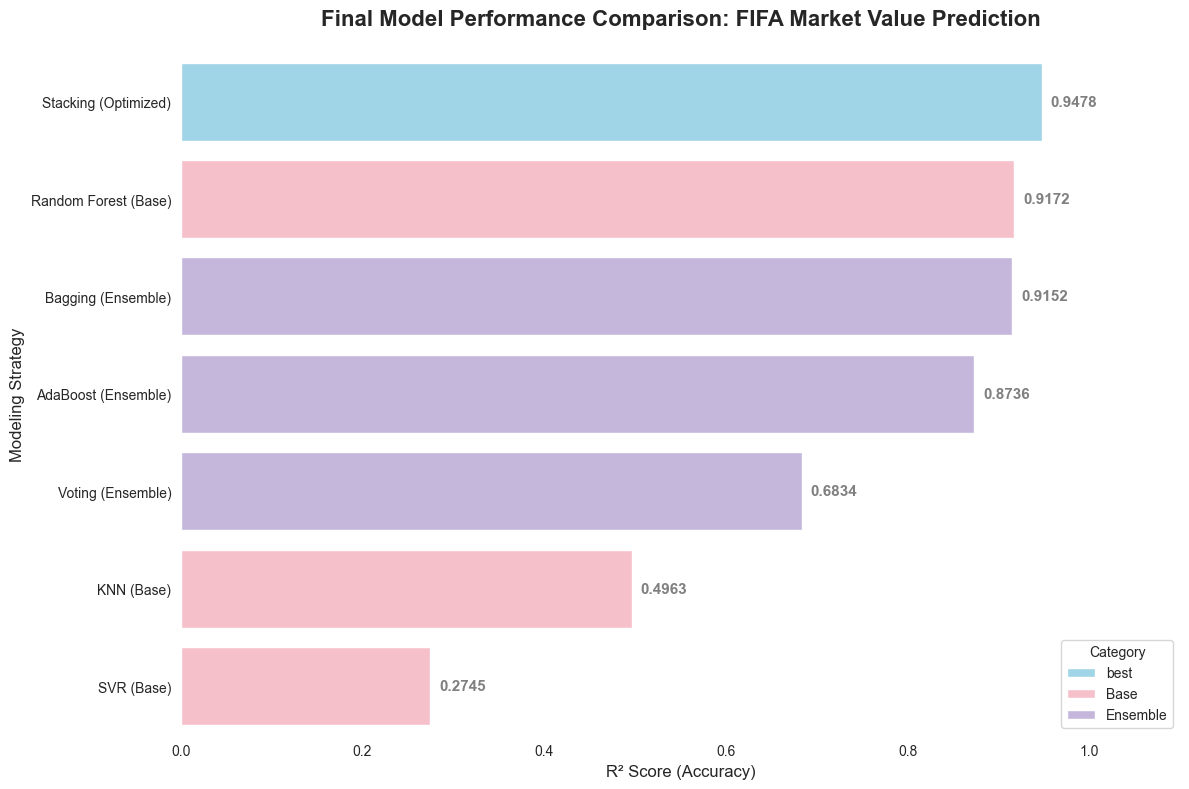

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Automatic Data Collection
visualization_data = {
    'Model Strategy': [
        'SVR (Base)', 
        'KNN (Base)', 
        'Random Forest (Base)',
        'Voting (Ensemble)', 
        'AdaBoost (Ensemble)', 
        'Bagging (Ensemble)', 
        'Stacking (Optimized)'
    ],
    'R2 Score': [
        r2_score(y_test, reg_models['SVR (RBF kernel)'].predict(X_test_scaled)), 
        r2_score(y_test, reg_models['KNN Regressor'].predict(X_test_scaled)),    
        r2_score(y_test, reg_models['Random Forest'].predict(X_test_scaled)),    
        r2_score(y_test, y_pred_vote),                                           
        r2_score(y_test, y_pred_boost),                                          
        r2_score(y_test, y_pred_bag),                                            
        grid_search.best_score_                                                  
    ],
    'Category': [
        'Base', 'Base', 'Base',
        'Ensemble', 'Ensemble', 'Ensemble', 'best' # Changed Stacking category to highlight it
    ]
}

# 2. Create DataFrame and sort
df_viz = pd.DataFrame(visualization_data).sort_values(by='R2 Score', ascending=False)

# 3. Custom Color Map: Pink for Base, Purple for Ensembles, Blue for Stacking
custom_palette = {
    'Base': '#FFB7C5',      # Pastel Pink
    'Ensemble': '#C3B1E1',  # Pastel Purple
    'best': "#94DAF3"     # Pastel Blue (Special for Stacking)
}

# 4. Create the plot
plt.figure(figsize=(12, 8))
sns.set_style("white") 

ax = sns.barplot(
    x='R2 Score', 
    y='Model Strategy', 
    data=df_viz, 
    palette=custom_palette, 
    hue='Category', 
    dodge=False,
    legend=True
)


plt.title('Final Model Performance Comparison: FIFA Market Value Prediction', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('R² Score (Accuracy)', fontsize=12)
plt.ylabel('Modeling Strategy', fontsize=12)
plt.xlim(0, 1.1) 


for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.4f}', 
                    (width + 0.01, p.get_y() + p.get_height() / 2), 
                    ha='left', va='center', 
                    fontsize=11, fontweight='bold', color='gray')

# 7. Final Styling
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

##  Optimization & Ensembling

1. What is Ensembling?

Instead of relying on one model, we combine multiple models to get a more accurate and stable prediction for FIFA player values.

2. Techniques Used

- Bagging: Trains multiple trees in parallel to reduce errors.

  Score: 0.9152

- Voting: Takes the average of KNN, SVM, and Random Forest.
   Score: 0.6834 (Lower because it averaged weak models)

- Boosting (AdaBoost): Focuses on fixing mistakes made by previous models.
 Score: 0.8736

- Stacking (The Winner): Uses a "Meta-Model" to learn which model to trust the most.
 Score: 0.9478 (After Tuning)

3. Why is Stacking the Best?

 We optimized the Stacking model using GridSearchCV with an Alpha of 10.0. This helped the model ignore "noise" from weak models and focus on the most accurate patterns, resulting in our highest accuracy of 94.7%.

##  Unified Inference Pipeline

Objective: Build a single pipeline that predicts both player value and performance tier using one interface.

In [13]:
import numpy as np
import pandas as pd

class UnifiedFIFAPipeline:

    def __init__(self, value_model, perf_model, scaler_reg, scaler_clf, feature_cols_reg, feature_cols_clf):
        """
        Store trained models + preprocessing tools
        """
        self.value_model = value_model
        self.perf_model = perf_model

        self.scaler_reg = scaler_reg
        self.scaler_clf = scaler_clf

        self.feature_cols_reg = feature_cols_reg
        self.feature_cols_clf = feature_cols_clf

  
    # PREPROCESS
   
    def preprocess(self, df, mode):

        df = df.copy()

        # check categorical columns before encoding
        if df.select_dtypes(include=['object']).shape[1] > 0:
            df = pd.get_dummies(df, drop_first=True)

        if mode == "regression":
            df = df.reindex(columns=self.feature_cols_reg, fill_value=0)
            return self.scaler_reg.transform(df)

        df = df.reindex(columns=self.feature_cols_clf, fill_value=0)
        return self.scaler_clf.transform(df)

   
    # PREDICT
  
    def predict(self, X):

        X_reg = self.preprocess(X, "regression")
        X_clf = self.preprocess(X, "classification")

        value_preds = self.value_model.predict(X_reg)
        tier_preds = self.perf_model.predict(X_clf)

        return [
            {
                "predicted_value": round( float(v),4),
                "performance_tier": t
            }
            for v, t in zip(value_preds, tier_preds)
        ]

### Preprocessing Strategy

- One-hot encoding is applied to categorical features  
- Feature alignment ensures consistency with training data  
- StandardScaler is applied (fit on training set only)  
- Separate feature pipelines are used for regression and classification  

### Prediction Flow

- Regression model is used to predict player value  
- Classification model is used to assign performance tier  
- Both models share the same input after preprocessing  

### Batch Prediction

The pipeline supports multiple inputs simultaneously, allowing predictions for multiple players in a single call.

In [14]:
# Example: Create pipeline using best models 

pipeline = UnifiedFIFAPipeline(
    value_model = reg_models['Random Forest'],        
    perf_model  = clf_models['SVC (RBF kernel)'],   
    scaler_reg  = scaler,
    scaler_clf  = scaler_clf,
    feature_cols_reg = X_train.columns,
    feature_cols_clf = X_train_clf_df.columns
)

In [15]:
import pandas as pd

sample_players = X_test.iloc[:5]
result = pipeline.predict(sample_players)

result_df = pd.DataFrame(result)

display(result_df)

,predicted_value,performance_tier
0,0.5055,Mid
1,20.0900,Elite
2,0.1801,Low
3,15.1350,Elite
4,0.5858,High


### Multi-Player Inference Capability

The pipeline is designed to handle multiple player profiles in a single prediction call instead of processing each player separately. This allows the system to work efficiently with batch inputs where all players are passed together as one dataset.

Each player in the input is processed independently through the same preprocessing and model pipeline. This ensures that predictions remain consistent and not affected by other samples in the batch.

As a result, the system returns one prediction per player while maintaining the same structure and order as the input data.

 ## Task 8: Cross-Validation Stability Assessment
# 
# Statistical proof of stability: mean ± std across 5 folds for every model.

In [ ]:
# %%
from sklearn.model_selection import cross_val_score

cv_stability = {}

print("=" * 70)
print("TASK 8: CROSS-VALIDATION STABILITY ASSESSMENT")
print("=" * 70)

# Regression models
print("\n>>> REGRESSION MODELS (R² Score)\n")
for name, model in optimized_reg_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_reg, scoring='r2')
    cv_stability[name] = {
        'task': 'regression', 'metric': 'R2',
        'mean': round(float(np.mean(scores)), 4),
        'std': round(float(np.std(scores)), 4),
        'all_fold_scores': [round(float(s), 4) for s in scores]
    }
    print(f"{name}")
    print(f"  Mean R² : {np.mean(scores):.4f}")
    print(f"  Std R²  : {np.std(scores):.4f}")
    print(f"  95% CI  : [{np.mean(scores)-1.96*np.std(scores):.4f}, {np.mean(scores)+1.96*np.std(scores):.4f}]")
    print(f"  Folds   : {[round(s,4) for s in scores]}\n")

# Classification models
print(">>> CLASSIFICATION MODELS (Accuracy)\n")
for name, model in optimized_clf_models.items():
    scores = cross_val_score(model, X_train_clf, y_train_clf, cv=cv_clf, scoring='accuracy')
    cv_stability[name] = {
        'task': 'classification', 'metric': 'Accuracy',
        'mean': round(float(np.mean(scores)), 4),
        'std': round(float(np.std(scores)), 4),
        'all_fold_scores': [round(float(s), 4) for s in scores]
    }
    print(f"{name}")
    print(f"  Mean Acc : {np.mean(scores):.4f}")
    print(f"  Std Acc  : {np.std(scores):.4f}")
    print(f"  95% CI   : [{np.mean(scores)-1.96*np.std(scores):.4f}, {np.mean(scores)+1.96*np.std(scores):.4f}]")
    print(f"  Folds    : {[round(s,4) for s in scores]}\n")

# Ensemble
print(">>> ENSEMBLE MODELS\n")
stack_scores = cross_val_score(grid_search.best_estimator_, X_train_scaled, y_train, cv=cv_reg, scoring='r2')
cv_stability['Optimized Stacking Regressor'] = {
    'task': 'regression', 'metric': 'R2',
    'mean': round(float(np.mean(stack_scores)), 4),
    'std': round(float(np.std(stack_scores)), 4),
    'all_fold_scores': [round(float(s), 4) for s in stack_scores]
}
print(f"Optimized Stacking Regressor")
print(f"  Mean R² : {np.mean(stack_scores):.4f}")
print(f"  Std R²  : {np.std(stack_scores):.4f}")
print(f"  Folds   : {[round(s,4) for s in stack_scores]}")


# ### Stability Summary Table

In [ ]:

summary_rows = []
for name, data in cv_stability.items():
    summary_rows.append({
        'Model': name, 'Task': data['task'], 'Metric': data['metric'],
        'Mean': data['mean'], 'Std': data['std'],
        '95% CI Lower': round(data['mean'] - 1.96*data['std'], 4),
        '95% CI Upper': round(data['mean'] + 1.96*data['std'], 4)
    })

stability_df = pd.DataFrame(summary_rows)
print("\nSTABILITY SUMMARY TABLE")
print("=" * 80)
print(stability_df.to_string(index=False))